## Imports
### Libraries

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

### Data 

In [2]:
X = pd.read_parquet('ETHUSDT_15m_features.parquet')

# RULE-BASED LABELS 
y_rule = pd.read_parquet("swing_labels.parquet").rename(
    columns={
        "y_high": "y_high_rule",
        "y_low":  "y_low_rule"})
# FRACTAL LABELS 
y_fractal = pd.read_parquet(
    "ETHUSDT_15m_fractal_labels_L10_R10.parquet", engine="fastparquet").rename(
    columns={
        "y_high": "y_high_fractal",
        "y_low":  "y_low_fractal"})

y_rule = y_rule.drop(columns=["segment_id"])
y_fractal = y_fractal.drop(columns=["segment_id"])

X = X.set_index("timestamp")
y_rule = y_rule.set_index("timestamp")
y_fractal = y_fractal.set_index("timestamp")

data = X.join(y_rule, how="inner").join(y_fractal, how="inner")

## Prepare the data

Check and handle NaNs

In [3]:
def check_nans(df):
    """
    Count NaNs per column and print summary with count and percentage.
    
    Args:
        df (pd.DataFrame): Input dataframe
    """
    total_rows = len(df)
    nan_summary = pd.DataFrame({
        "n_nan": df.isna().sum(),
        "perc_nan": df.isna().mean() * 100
    }).sort_values("perc_nan", ascending=False)
    
    print(f"Total rows: {total_rows}\n")
    print(nan_summary)
    return nan_summary

nan_report = check_nans(data)

Total rows: 139219

                     n_nan  perc_nan
vol_50                 100  0.071829
roll_min_50             98  0.070393
dist_to_roll_max_50     98  0.070393
roll_max_50             98  0.070393
dist_to_roll_min_50     98  0.070393
vol_20                  40  0.028732
dist_to_roll_min_20     38  0.027295
dist_to_roll_max_20     38  0.027295
roll_max_20             38  0.027295
roll_min_20             38  0.027295
ret_10                  20  0.014366
ret_3                    6  0.004310
ret_1                    2  0.001437
lower_wick               0  0.000000
upper_wick               0  0.000000
segment_id               0  0.000000
range                    0  0.000000
body                     0  0.000000
open                     0  0.000000
high                     0  0.000000
low                      0  0.000000
close                    0  0.000000
volume                   0  0.000000
y_high_rule              0  0.000000
y_low_rule               0  0.000000
y_high_fractal    

In [4]:
X =  X.fillna(0)

Prepare features for ml

In [5]:
def prepare_features_for_ml(df, target_cols, exclude_cols=None):
    """
    Fill NaNs and scale all numeric features for ML.
    
    Args:
        df (pd.DataFrame): full dataset with features and targets
        target_cols (list): list of target columns to exclude from scaling
        exclude_cols (list): optional list of columns to exclude from scaling (e.g., 'segment_id')
    
    Returns:
        X_scaled (pd.DataFrame): scaled features
        y (pd.DataFrame): targets
        scaler (StandardScaler): fitted scaler object
    """
    
    if exclude_cols is None:
        exclude_cols = []

    # Separate features and targets
    y = df[target_cols].copy()
    X = df.drop(columns=target_cols + exclude_cols)
    
    # Standard Scaling
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X_filled),
        columns=X_filled.columns,
        index=X_filled.index
    )
    
    return X_scaled, y, scaler

target_cols = ["y_high_rule", "y_low_rule", "y_high_fractal", "y_low_fractal"]
exclude_cols = ["segment_id"]

X_scaled, y, scaler = prepare_features_for_ml(data, target_cols, exclude_cols)

print("Scaled features preview:")
print(X_scaled.head())

Scaled features preview:
                              ret_1     ret_3    ret_10     range      body  \
timestamp                                                                     
2021-07-05 12:00:00+00:00 -0.001874 -0.003247 -0.005864  1.610741  1.068818   
2021-07-05 12:15:00+00:00  0.374663 -0.003247 -0.005864  0.006791 -0.318624   
2021-07-05 12:30:00+00:00  0.239244 -0.003247 -0.005864 -0.201872 -0.491240   
2021-07-05 12:45:00+00:00 -0.413309  0.115187 -0.005864 -0.559997 -0.272531   
2021-07-05 13:00:00+00:00  1.611795  0.827359 -0.005864  0.744557  1.250178   

                           upper_wick  lower_wick  roll_max_20  roll_min_20  \
timestamp                                                                     
2021-07-05 12:00:00+00:00    1.068732    1.310531     -2.85879    -2.865435   
2021-07-05 12:15:00+00:00    1.422749   -0.641879     -2.85879    -2.865435   
2021-07-05 12:30:00+00:00    0.444666   -0.038382     -2.85879    -2.865435   
2021-07-05 12:45:00+00:00 

## Feature selection

Setup features and targets

In [6]:
targets = ["y_high_rule", "y_low_rule", "y_high_fractal", "y_low_fractal"]

Time-based train/test split (80/20)

In [7]:
split_idx = int(len(X_scaled) * 0.8)

X_train, X_test = X_scaled.iloc[:split_idx], X_scaled.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

Feature evaluation

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc
import pandas as pd
import numpy as np

def compute_feature_importance(X_scaled, y, solver="lbfgs", max_iter=500):
    """
    Compute feature importance using LogisticRegression coefficients
    and PR-AUC for each feature (univariate).
    
    Args:
        X_scaled (pd.DataFrame): scaled features
        y (pd.DataFrame): targets (can have multiple columns)
        solver (str): solver for LogisticRegression
        max_iter (int): max iterations for convergence
    
    Returns:
        importance_dict (dict): feature importance per target
    """
    importance_dict = {}
    
    for target in y.columns:
        coefs = {}
        pr_aucs = {}
        
        for feature in X_scaled.columns:
            # Fit logistic regression for a single feature
            model = LogisticRegression(solver=solver, max_iter=max_iter)
            model.fit(X_scaled[[feature]], y[target])
            
            # Coefficient as importance
            coefs[feature] = abs(model.coef_[0][0])
            
            # PR-AUC for single feature
            probs = model.predict_proba(X_scaled[[feature]])[:, 1]
            precision, recall, _ = precision_recall_curve(y[target], probs)
            pr_aucs[feature] = auc(recall, precision)
        
        # Combine into DataFrame for this target
        df = pd.DataFrame({
            "coef_abs": pd.Series(coefs),
            "pr_auc": pd.Series(pr_aucs)
        }).sort_values("pr_auc", ascending=False)
        
        importance_dict[target] = df
    
    return importance_dict

importance = compute_feature_importance(X_scaled, y)

                     coef_abs    pr_auc
ret_1                1.130116  0.323051
ret_3                0.935475  0.283299
dist_to_roll_max_20  0.860801  0.261148
dist_to_roll_max_50  0.398471  0.211910
lower_wick           0.362492  0.204440
ret_10               0.496261  0.188520
dist_to_roll_min_20  0.291205  0.171038
body                 0.217282  0.160812
dist_to_roll_min_50  0.215653  0.149110
range                0.103334  0.134544


Feature RP-AUC Heatmap

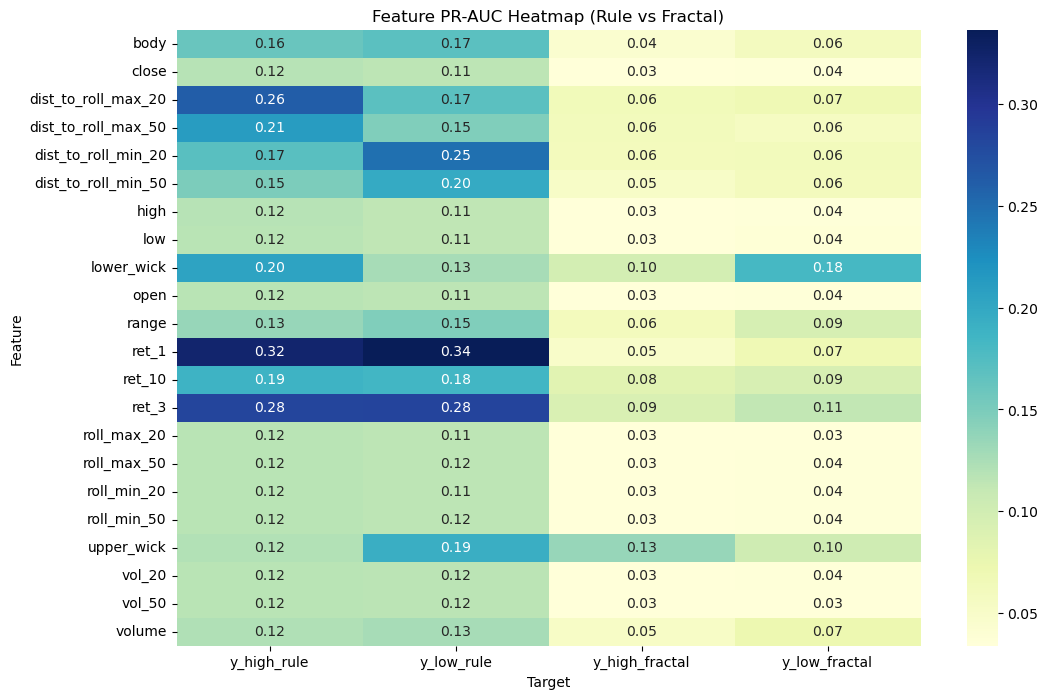

In [11]:
# Combine importance DataFrames for PR-AUC only
df_pr_auc = pd.DataFrame({
    target: importance[target]["pr_auc"] for target in importance
})

plt.figure(figsize=(12, 8))
sns.heatmap(df_pr_auc, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Feature PR-AUC Heatmap (Rule vs Fractal)")
plt.xlabel("Target")
plt.ylabel("Feature")
plt.show()

Cannot do manually, so use backward feature elimination

In [14]:
def backward_feature_elimination_multi(X, y, min_features=5, tolerance=0.001, solver="lbfgs", max_iter=500):
    """
    Multi-target backward feature elimination.
    Removes a feature only if it's safe for all targets.
    
    Args:
        X (pd.DataFrame): scaled features
        y (pd.DataFrame): targets (multiple columns)
        min_features (int): minimum number of features to keep
        tolerance (float): max allowed drop in PR-AUC
        solver (str): LogisticRegression solver
        max_iter (int): max iterations
    
    Returns:
        remaining_features (list)
        history (pd.DataFrame)
    """
    features = list(X.columns)
    history = []

    current_X = X.copy()
    
    while len(features) > min_features:
        safe_to_remove = []
        pr_aucs_drop = {}
        
        for f in features:
            drop_safe = True
            auc_drop_per_target = {}
            
            for target in y.columns:
                # PR-AUC with all features
                model_all = LogisticRegression(solver=solver, max_iter=max_iter)
                model_all.fit(current_X, y[target])
                probs_all = model_all.predict_proba(current_X)[:, 1]
                precision, recall, _ = precision_recall_curve(y[target], probs_all)
                pr_auc_all = auc(recall, precision)
                
                # PR-AUC without this feature
                model_drop = LogisticRegression(solver=solver, max_iter=max_iter)
                model_drop.fit(current_X.drop(columns=[f]), y[target])
                probs_drop = model_drop.predict_proba(current_X.drop(columns=[f]))[:, 1]
                precision, recall, _ = precision_recall_curve(y[target], probs_drop)
                pr_auc_drop = auc(recall, precision)
                
                auc_drop_per_target[target] = pr_auc_all - pr_auc_drop
                if pr_auc_all - pr_auc_drop > tolerance:
                    drop_safe = False
            
            if drop_safe:
                safe_to_remove.append(f)
                pr_aucs_drop[f] = auc_drop_per_target
        
        if not safe_to_remove:
            break  # no more safe features to drop
        
        # remove the first safe feature
        feature_to_remove = safe_to_remove[0]
        current_X = current_X.drop(columns=[feature_to_remove])
        features.remove(feature_to_remove)
        history.append({"removed": feature_to_remove, "pr_auc_drop": pr_aucs_drop[feature_to_remove]})
    
    history_df = pd.DataFrame(history)
    return list(current_X.columns), history_df

selected_features, elimination_history = backward_feature_elimination_multi(
    X_train, y_train, min_features=5, tolerance=0.001
)

print("Selected features after multi-target BFE:")
print(selected_features)
print("\nElimination history:")
print(elimination_history)


Selected features after multi-target BFE:
['ret_1', 'ret_3', 'body', 'upper_wick', 'lower_wick', 'dist_to_roll_max_20', 'dist_to_roll_min_20', 'vol_50']

Elimination history:
                removed                                        pr_auc_drop
0                ret_10  {'y_high_rule': 6.943371215478722e-05, 'y_low_...
1                 range  {'y_high_rule': -0.00028144611359975924, 'y_lo...
2           roll_max_20  {'y_high_rule': 0.0001028183492569057, 'y_low_...
3           roll_min_20  {'y_high_rule': -0.0002084131052694782, 'y_low...
4                vol_20  {'y_high_rule': 0.0004072145709778652, 'y_low_...
5           roll_max_50  {'y_high_rule': -2.202548193291909e-05, 'y_low...
6           roll_min_50  {'y_high_rule': 1.4959420773119625e-05, 'y_low...
7   dist_to_roll_min_50  {'y_high_rule': 3.8171137657916354e-05, 'y_low...
8   dist_to_roll_max_50  {'y_high_rule': -0.0005820274903994282, 'y_low...
9                  open  {'y_high_rule': 0.00013787877390891712, 'y_low...


Create df with only selected features

In [20]:
X_selected = X_scaled[selected_features].copy()

print(f"Original features: {X_scaled.shape[1]}")
print(f"Selected features: {X_selected.shape[1]}")

# Preview
X_selected.head()

Original features: 22
Selected features: 8


,ret_1,ret_3,body,upper_wick,lower_wick,dist_to_roll_max_20,dist_to_roll_min_20,vol_50
timestamp,,,,,,,,
2021-07-05 12:00:00+00:00,-0.001874,-0.003247,1.068818,1.068732,1.310531,-0.90417,-1.003044,-1.695673
2021-07-05 12:15:00+00:00,0.374663,-0.003247,-0.318624,1.422749,-0.641879,-0.90417,-1.003044,-1.695673
2021-07-05 12:30:00+00:00,0.239244,-0.003247,-0.491240,0.444666,-0.038382,-0.90417,-1.003044,-1.695673
2021-07-05 12:45:00+00:00,-0.413309,0.115187,-0.272531,-0.515472,-0.504563,-0.90417,-1.003044,-1.695673
2021-07-05 13:00:00+00:00,1.611795,0.827359,1.250178,-0.082222,-0.211989,-0.90417,-1.003044,-1.695673


Check heatmap again to see what do we have

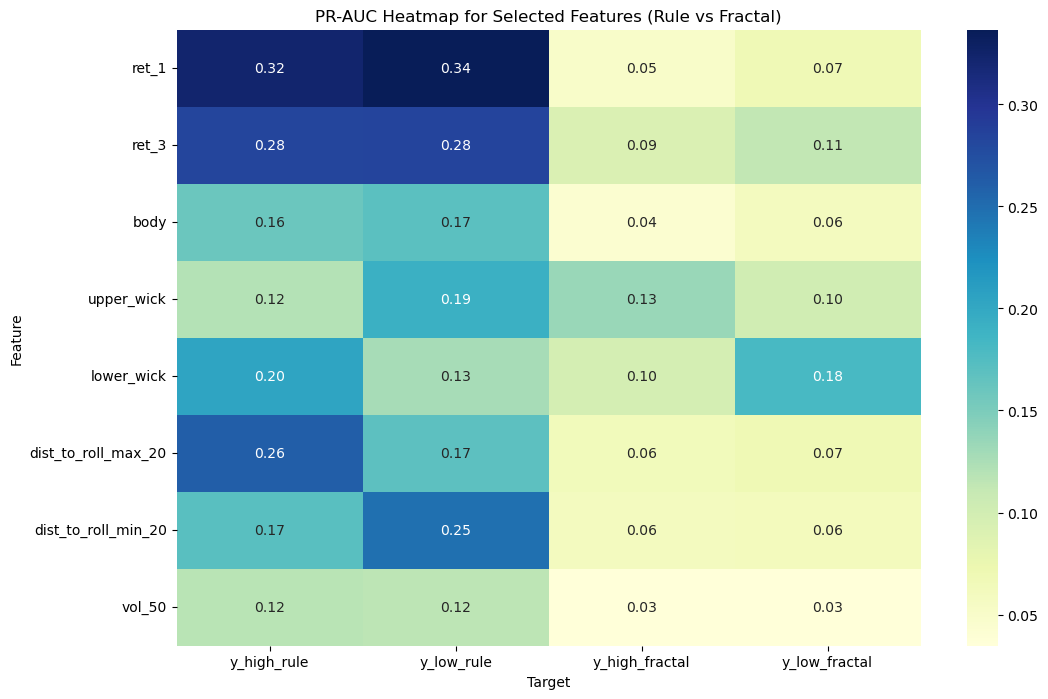

In [21]:
# Create a DataFrame from importance_dict for heatmap
importance_df = pd.DataFrame({
    target: importance_dict[target]["pr_auc"] 
    for target in importance_dict
})

# Keep only the selected features
importance_df = importance_df.loc[X_selected.columns]

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(importance_df.astype(float), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("PR-AUC Heatmap for Selected Features (Rule vs Fractal)")
plt.xlabel("Target")
plt.ylabel("Feature")
plt.show()

Correlation matrix to be sure that there are no useless features

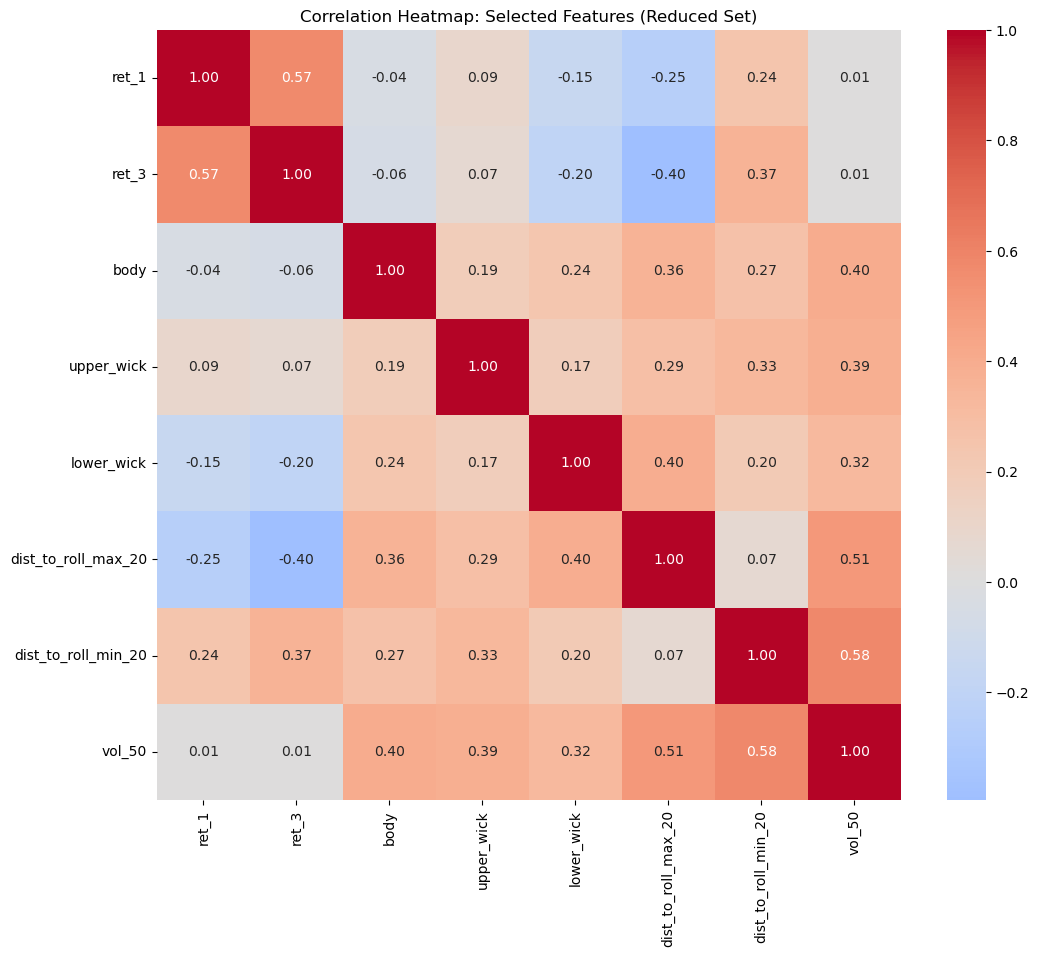

In [26]:
corr_selected = X_selected.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_selected,       # correlation matrix
    annot=True,          # show numbers
    fmt=".2f",           # two decimal places
    cmap='coolwarm',     # color map
    center=0
)
plt.title("Correlation Heatmap: Selected Features (Reduced Set)")
plt.show()


## Sanity check 
### To be sure that we didn't drop important features

In [27]:
def sanity_check_feature_selection(X_full, X_selected, y):
    """
    Compare predictive performance of full features vs selected features.
    
    Args:
        X_full (pd.DataFrame): original full feature matrix (scaled)
        X_selected (pd.DataFrame): features selected via BFE
        y (pd.DataFrame): target dataframe with multiple targets
    """
    results = []

    for target in y.columns:
        print(f"\n=== Target: {target} ===")
        
        # Full features
        model_full = LogisticRegression(max_iter=500)
        model_full.fit(X_full, y[target])
        probs_full = model_full.predict_proba(X_full)[:, 1]
        precision_f, recall_f, _ = precision_recall_curve(y[target], probs_full)
        pr_auc_full = auc(recall_f, precision_f)
        print(f"Full features PR-AUC: {pr_auc_full:.4f}")
        
        # Selected features
        model_sel = LogisticRegression(max_iter=500)
        model_sel.fit(X_selected, y[target])
        probs_sel = model_sel.predict_proba(X_selected)[:, 1]
        precision_s, recall_s, _ = precision_recall_curve(y[target], probs_sel)
        pr_auc_sel = auc(recall_s, precision_s)
        print(f"Selected features PR-AUC: {pr_auc_sel:.4f}")
        
        results.append({
            "target": target,
            "pr_auc_full": pr_auc_full,
            "pr_auc_selected": pr_auc_sel,
            "drop_in_performance": pr_auc_full - pr_auc_sel
        })
    
    return pd.DataFrame(results)

sanity_df = sanity_check_feature_selection(X_scaled, X_selected, y)
print("\nSummary table:")
print(sanity_df)



=== Target: y_high_rule ===
Full features PR-AUC: 0.3893
Selected features PR-AUC: 0.3898

=== Target: y_low_rule ===
Full features PR-AUC: 0.4012
Selected features PR-AUC: 0.4007

=== Target: y_high_fractal ===
Full features PR-AUC: 0.3009
Selected features PR-AUC: 0.2991

=== Target: y_low_fractal ===
Full features PR-AUC: 0.3207
Selected features PR-AUC: 0.3200

Summary table:
           target  pr_auc_full  pr_auc_selected  drop_in_performance
0     y_high_rule     0.389291         0.389775            -0.000484
1      y_low_rule     0.401178         0.400657             0.000521
2  y_high_fractal     0.300859         0.299109             0.001750
3   y_low_fractal     0.320685         0.320023             0.000662


### Save the reduced features df

In [29]:
X_selected.to_parquet("ETHUSDT_15m_features_reduced.parquet")